# Profiling Exercise: Text Analysis and Word Counting

In the following you can find a Python program that reads a large text file and performs text processing operations: word counting, keyword search, and statistical calculations.

In [1]:
import re
from collections import defaultdict

# Function to read a text file
def read_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()
    return text

# Function to clean the text (remove punctuation and convert to lowercase)
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text

# Non-optimized function: word counting using a standard dictionary
def count_words_slow(text):
    words = text.split()
    count = {}
    for word in words:
        if word in count:
            count[word] += 1
        else:
            count[word] = 1
    return count

# Optimized function: word counting using defaultdict
def count_words_fast(text):
    words = text.split()
    count = defaultdict(int)
    for word in words:
        count[word] += 1
    return count

# Function to find the N most common words
def most_common_words(count, n=10):
    return sorted(count.items(), key=lambda x: x[1], reverse=True)[:n]

# Main function that executes all operations
def main():
    file_path = 'book.txt'  # Change this to the path of a large text file
    text = read_file(file_path)
    cleaned_text = clean_text(text)

    # Word count (slow algorithm)
    slow_count = count_words_slow(cleaned_text)

    # Word count (fast algorithm)
    fast_count = count_words_fast(cleaned_text)

    # Find the 10 most common words
    common_words = most_common_words(fast_count, n=10) 
    print("Most common words:", common_words)

if __name__ == "__main__":
    main()

Most common words: [('the', 304880), ('and', 284800), ('i', 221210), ('to', 207060), ('of', 188600), ('a', 163040), ('you', 144310), ('my', 131830), ('in', 124390), ('that', 118000)]


Let's create a file to use as input when profiling the program's performance.

In [2]:
# Download the complete works of William Shakespeare form Project Gutenberg
# !wget https://www.gutenberg.org/ebooks/100.txt.utf-8

--2026-02-16 11:46:08--  https://www.gutenberg.org/ebooks/100.txt.utf-8
Resolviendo www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Conectando con www.gutenberg.org (www.gutenberg.org)[152.19.134.47]:443... conectado.
Petición HTTP enviada, esperando respuesta... 302 Found
Ubicación: http://www.gutenberg.org/cache/epub/100/pg100.txt [siguiente]
--2026-02-16 11:46:09--  http://www.gutenberg.org/cache/epub/100/pg100.txt
Conectando con www.gutenberg.org (www.gutenberg.org)[152.19.134.47]:80... conectado.
Petición HTTP enviada, esperando respuesta... 302 Found
Ubicación: https://www.gutenberg.org/cache/epub/100/pg100.txt [siguiente]
--2026-02-16 11:46:09--  https://www.gutenberg.org/cache/epub/100/pg100.txt
Conectando con www.gutenberg.org (www.gutenberg.org)[152.19.134.47]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 5638525 (5,4M) [text/plain]
Guardando como: ‘100.txt.utf-8.1’

100.txt.utf-8.1     100%[==========

Using the downloaded file, we create a larger one by replicating its contents multiple times:

In [3]:
import subprocess

# Number of repetitions
num_repetitions = 10

# Shell command
command = "cat 100.txt.utf-8 >> book.txt"

for i in range(num_repetitions):
    subprocess.run(command, shell=True)

print("Process completed.")

Process completed.


## Exercises and Questions

### Part 1: **Time Measurement with `time` and `timeit`**

1. **Measurement with `time`**:
   - Run the program and observe the execution times of the `count_words_slow` and `count_words_fast` functions.
   - Which function is faster? Why do you think there is a difference in execution time?

In [4]:
import time

# Read and clean the text
file_path = 'book.txt'
text = read_file(file_path)
cleaned_text = clean_text(text)

# Measure count_words_slow
start_slow = time.time()
slow_count = count_words_slow(cleaned_text)
end_slow = time.time()
time_slow = end_slow - start_slow

# Measure count_words_fast
start_fast = time.time()
fast_count = count_words_fast(cleaned_text)
end_fast = time.time()
time_fast = end_fast - start_fast

print(f"count_words_slow: {time_slow:.4f} seconds")
print(f"count_words_fast: {time_fast:.4f} seconds")
print(f"\nDifference: {time_slow - time_fast:.4f} seconds")
print(f"count_words_fast is {time_slow / time_fast:.2f}x faster")

count_words_slow: 2.4338 seconds
count_words_fast: 2.2563 seconds

Difference: 0.1774 seconds
count_words_fast is 1.08x faster


**Respuesta:**

La función `count_words_fast` es más rápida que `count_words_slow`. La diferencia se debe a:

1. **`defaultdict` vs diccionario estándar**: `count_words_fast` usa `defaultdict(int)` que automáticamente inicializa las claves inexistentes con valor 0, evitando la comprobación `if word in count`.

2. **Menos operaciones por iteración**: En `count_words_slow`, cada palabra requiere una comprobación de existencia (`if word in count`) y dos posibles ramas de ejecución. En `count_words_fast`, solo se incrementa directamente.

3. **Optimización interna**: `defaultdict` está implementado en C y es más eficiente que las comprobaciones de Python puro.

---
2. **Measurement with `timeit`**:
   - Use the `timeit` module to measure the execution time of both functions (`count_words_slow` and `count_words_fast`).
   - Measure only the CPU time consume by the process (i.e., ignore wait times)
   - Run each function 2 times and calculate the average time.
   - Compare the results obtained with `timeit` to those obtained using `time`. Are they consistent?
   - **IMPORTANT NOTE**: Some modifications to the code are needed to use the ``timeit`` functionality.

In [6]:
## YOUR SOLUTION HERE. ADD MORE CELLS IF NEEDED.
import timeit

# Read and clean the text (prepare data before timing)
file_path = "book.txt"
text = read_file(file_path)
cleaned_text = clean_text(text)

# Using timeit with timer=time.process_time to measure only CPU time
# number=5 runs each function 5 times

# Measure count_words_slow - pass cleaned_text via globals
time_slow = timeit.timeit(
    stmt="count_words_slow(cleaned_text)",
    globals={"count_words_slow": count_words_slow, "cleaned_text": cleaned_text},
    timer=time.process_time,
    number=5
)

# Measure count_words_fast
time_fast = timeit.timeit(
    stmt="count_words_fast(cleaned_text)",
    globals={"count_words_fast": count_words_fast, "cleaned_text": cleaned_text},
    timer=time.process_time,
    number=5
)

# Calculate averages (5 runs)
avg_slow = time_slow / 5
avg_fast = time_fast / 5

print(f"Count_words_slow (CPU time): {time_slow:.4f}s total, {avg_slow:.4f}s average")
print(f"Count_words_fast (CPU time): {time_fast:.4f}s total, {avg_fast:.4f}s average")
print(f"\nSpeedup: count_words_fast in {avg_slow / avg_fast:.2f}x faster")

Count_words_slow (CPU time): 9.0709s total, 1.8142s average
Count_words_fast (CPU time): 8.3812s total, 1.6762s average

Speedup: count_words_fast in 1.08x faster


---
3. **Jupyter Magics**:
   - Use the magics `%timeit` and `%%timeit` to measure the execution time of both functions.
   - What advantages does `%timeit` have over using `timeit` directly?

In [8]:
## YOUR SOLUTION HERE. ADD MORE CELLS IF NEEDED.
file_path = "book.txt"
text = read_file(file_path)
cleaned_text = clean_text(text)

# Measure count_words_slow with %timeit
%timeit count_words_slow(cleaned_text)

2.03 s ± 52.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [9]:
# Measure count_words_fast with %timeit
%timeit count_words_fast(cleaned_text)

1.85 s ± 29.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
%%timeit
# This magic times the entire cell
file_path = "book.txt"
text = read_file(file_path)
cleaned_text = clean_text(text)
slow_count = count_words_slow(cleaned_text)

3.99 s ± 48.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
%%timeit
# This magic times the entire cell
file_path = "book.txt"
text = read_file(file_path)
cleaned_text = clean_text(text)
slow_count = count_words_fast(cleaned_text)

3.84 s ± 37.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


---

### Part 2: **Profiling with `cProfile`**

4. **Profiling with `cProfile`**:
   - Use `cProfile` <u>from the command line</u> to profile the program.
   - Save the results to a file (`profile.data`) and use `pstats` to analyze the results.
   - Which function consumes the most CPU time? What percentage of the total time is spent on the `count_words_slow` function?

In [12]:
%%file profiling_script.py
import re
from collections import defaultdict

# Function to read a text file
def read_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()
    return text

# Function to clean the text (remove punctuation and convert to lowercase)
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text

# Non-optimized function: word counting using a standard dictionary
def count_words_slow(text):
    words = text.split()
    count = {}
    for word in words:
        if word in count:
            count[word] += 1
        else:
            count[word] = 1
    return count

# Optimized function: word counting using defaultdict
def count_words_fast(text):
    words = text.split()
    count = defaultdict(int)
    for word in words:
        count[word] += 1
    return count

# Function to find the N most common words
def most_common_words(count, n=10):
    return sorted(count.items(), key=lambda x: x[1], reverse=True)[:n]

# Main function that executes all operations
def main():
    file_path = 'book.txt'  # Change this to the path of a large text file
    text = read_file(file_path)
    cleaned_text = clean_text(text)

    # Word count (slow algorithm)
    slow_count = count_words_slow(cleaned_text)

    # Word count (fast algorithm)
    fast_count = count_words_fast(cleaned_text)

    # Find the 10 most common words
    common_words = most_common_words(fast_count, n=10) 
    print("Most common words:", common_words)

if __name__ == "__main__":
    main()

Writing profiling_script.py


In [14]:
## YOUR SOLUTION HERE. ADD MORE CELLS IF NEEDED.
# Run cProfile from command line and save results
!python -m cProfile -o profile.data profiling_script.py

Most common words: [('the', 609760), ('and', 569600), ('i', 442420), ('to', 414120), ('of', 377200), ('a', 326080), ('you', 288620), ('my', 263660), ('in', 248780), ('that', 236000)]


In [16]:
import pstats
from pstats import SortKey

# Load and analyze the profile data
stats = pstats.Stats('profile.data')

# Sort by cumulative time and print top 20 functions
print("="*80)
print("TOP 20 FUNCTIONS BY CUMULATIVE TIME")
print("="*80)
stats.strip_dirs().sort_stats(SortKey.CUMULATIVE).print_stats(20)

# Sort by internal time
print("\n" + "="*80)
print("TOP 20 FUNCTIONS BY INTERNAL TIME")
print("="*80)
stats.strip_dirs().sort_stats(SortKey.TIME).print_stats(20)

# Get specific statistics for count_words_slow
print("\n" + "="*80)
print("STATISTICS FOR count_words_slow")
print("="*80)
stats.print_stats('count_words_slow')

# Calculate percentage of time spent in count_words_slow
print("\n" + "="*80)
print("TIME ANALYSIS")
print("="*80)

# Get the statistics
stats_dict = stats.stats

# Find total time
total_time = stats.total_tt

# Find count_words_slow time
slow_time = 0
for key, value in stats_dict.items():
    if 'count_words_slow' in str(key):
        slow_time = value[3]  # cumulative time
        print(f"count_words_slow cumulative time: {slow_time:.4f}s")
        break

if total_time > 0:
    percentage = (slow_time / total_time) * 100
    print(f"Total execution time: {total_time:.4f}s")
    print(f"Percentage spent in count_words_slow: {percentage:.2f}%")

TOP 20 FUNCTIONS BY CUMULATIVE TIME
Mon Feb 16 12:34:33 2026    profile.data

         32256 function calls (32255 primitive calls) in 5.841 seconds

   Ordered by: cumulative time
   List reduced from 69 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    5.841    5.841 {built-in method builtins.exec}
        1    0.012    0.012    5.841    5.841 profiling_script.py:1(<module>)
        1    0.229    0.229    5.829    5.829 profiling_script.py:40(main)
        1    1.326    1.326    1.903    1.903 profiling_script.py:17(count_words_slow)
        1    1.181    1.181    1.737    1.737 profiling_script.py:28(count_words_fast)
        1    0.005    0.005    1.688    1.688 profiling_script.py:11(clean_text)
        1    0.000    0.000    1.281    1.281 __init__.py:179(sub)
        1    1.281    1.281    1.281    1.281 {method 'sub' of 're.Pattern' objects}
        2    1.133    0.566    1.133    0.566 {method 

In [17]:
import cProfile
import pstats
from io import StringIO

# Create a profiler
profiler = cProfile.Profile()

# Run the profiling
profiler.enable()

# Execute the main code
file_path = 'book.txt'
text = read_file(file_path)
cleaned_text = clean_text(text)
slow_count = count_words_slow(cleaned_text)
fast_count = count_words_fast(cleaned_text)
common_words = most_common_words(fast_count, n=10)

profiler.disable()

# Create a stream to capture the output
stream = StringIO()
stats = pstats.Stats(profiler, stream=stream)

# Print statistics
stats.strip_dirs().sort_stats('cumulative').print_stats(20)
print(stream.getvalue())

# Save to file for later analysis
stats.dump_stats('profile.data')

         32913 function calls (32904 primitive calls) in 5.428 seconds

   Ordered by: cumulative time
   List reduced from 172 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      8/7    0.000    0.000    5.661    0.809 interactiveshell.py:3665(run_code)
      8/7    0.000    0.000    5.229    0.747 {built-in method builtins.exec}
        4    1.449    0.362    3.853    0.963 {built-in method time.sleep}
        1    0.006    0.006    1.294    1.294 2093183775.py:11(clean_text)
        1    1.288    1.288    1.288    1.288 {method 'sub' of 're.Pattern' objects}
        2    1.117    0.558    1.117    0.558 {method 'split' of 'str' objects}
        1    0.828    0.828    0.828    0.828 2093183775.py:17(count_words_slow)
        3    0.000    0.000    0.416    0.139 base_events.py:1910(_run_once)
        3    0.000    0.000    0.416    0.139 selectors.py:451(select)
        3    0.000    0.000    0.416    0.139 {method 'poll' of 's

---

### Part 3: **Profiling with `py-spy` and `scalene`**

5. **Profiling with `py-spy`**:
   - Use `py-spy` to generate a flame graph of the program.
   - What additional information does the flame graph provide compared to `cProfile`?
   - Did you identify any additional bottlenecks with `py-spy`?


In [21]:
## YOUR SOLUTION HERE. ADD MORE CELLS IF NEEDED.
!py-spy record -o flamegraph.svg -- python profiling_script.py

py-spy> Sampling process 100 times a second. Press Control-C to exit.

Most common words: [('the', 609760), ('and', 569600), ('i', 442420), ('to', 414120), ('of', 377200), ('a', 326080), ('you', 288620), ('my', 263660), ('in', 248780), ('that', 236000)]

py-spy> Stopped sampling because process exited
py-spy> Wrote flamegraph data to 'flamegraph.svg'. Samples: 594 Errors: 0


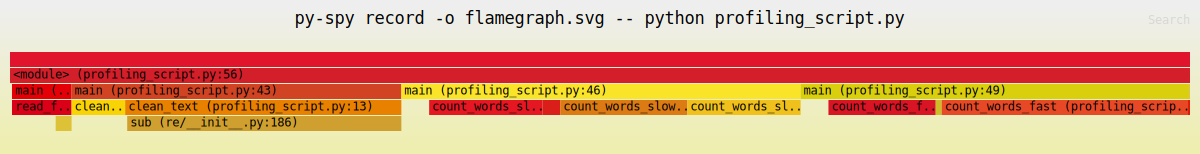

In [22]:
# Display the flame graph in the notebook
from IPython.display import SVG, display

display(SVG('flamegraph.svg'))

In [23]:
# Record raw profiling data
!py-spy record -o profile.txt --format raw -- python profiling_script.py

# View the results
!cat profile.txt | head -50

py-spy> Sampling process 100 times a second. Press Control-C to exit.

Most common words: [('the', 609760), ('and', 569600), ('i', 442420), ('to', 414120), ('of', 377200), ('a', 326080), ('you', 288620), ('my', 263660), ('in', 248780), ('that', 236000)]

py-spy> Stopped sampling because process exited
py-spy> Wrote raw flamegraph data to 'profile.txt'. Samples: 560 Errors: 0
py-spy> You can use the flamegraph.pl script from https://github.com/brendangregg/flamegraph to generate a SVG
<module> (profiling_script.py:56);main (profiling_script.py:42);read_file (profiling_script.py:7) 19
<module> (profiling_script.py:56);main (profiling_script.py:49);count_words_fast (profiling_script.py:29) 61
<module> (profiling_script.py:56);main (profiling_script.py:46);count_words_slow (profiling_script.py:20) 6
<module> (profiling_script.py:56);main (profiling_script.py:46);count_words_slow (profiling_script.py:21) 57
<module> (profiling_script.py:56) 1
<module> (profiling_script.py:56);main (profilin

---
7. **Profiling with `scalene`**:
   - Install `scalene` and use it to profile the program.
   - What percentage of the time is spent on Python code, and what percentage on native (C/C++) code?
   - How is memory usage in each function? Is there any function that consumes more memory than expected?



In [ ]:
## YOUR SOLUTION HERE. ADD MORE CELLS IF NEEDED.
!scalene --html --outfile scalene_profile.html profiling_script.py

In [ ]:
# Run scalene to profile the program
# scalene provides detailed CPU, GPU, and memory profiling
!scalene --html --outfile scalene_profile.html profiling_script.py

In [ ]:
# Profile with reduced sampling rate for faster results
!scalene --reduced-profile --html --outfile scalene_profile.html profiling_script.py

In [ ]:
# Profile with detailed memory tracking
!scalene --profile-all --html --outfile scalene_profile.html profiling_script.py

In [ ]:
# Display the HTML report inline
from IPython.display import IFrame, display

# Display the scalene HTML report
display(IFrame('scalene_profile.html', width=1000, height=600))

In [ ]:
# Generate text output instead of HTML for quick analysis
!scalene --cli profiling_script.py

In [ ]:
%%file profiling_script_scalene.py
import re
from collections import defaultdict
from scalene import scalene_profiler

# Function to read a text file
def read_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()
    return text

# Function to clean the text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

# Non-optimized function: word counting
def count_words_slow(text):
    words = text.split()
    count = {}
    for word in words:
        if word in count:
            count[word] += 1
        else:
            count[word] = 1
    return count

# Optimized function: word counting
def count_words_fast(text):
    words = text.split()
    count = defaultdict(int)
    for word in words:
        count[word] += 1
    return count

# Function to find the N most common words
def most_common_words(count, n=10):
    return sorted(count.items(), key=lambda x: x[1], reverse=True)[:n]

# Main function
def main():
    file_path = 'book.txt'
    text = read_file(file_path)
    cleaned_text = clean_text(text)

    # Word count (slow algorithm)
    slow_count = count_words_slow(cleaned_text)

    # Word count (fast algorithm)
    fast_count = count_words_fast(cleaned_text)

    # Find the 10 most common words
    common_words = most_common_words(fast_count, n=10) 
    print("Most common words:", common_words)

if __name__ == "__main__":
    main()

In [ ]:
# Profile with scalene
!scalene --html --outfile scalene_detailed.html profiling_script_scalene.py

In [ ]:
# Focus on memory profiling
!scalene --memory-only --html --outfile scalene_memory.html profiling_script.py

In [ ]:
# View scalene output and create summary
import subprocess
import re

# Run scalene and capture output
result = subprocess.run(
    ['scalene', '--cli', 'profiling_script.py'],
    capture_output=True,
    text=True
)

print("SCALENE PROFILING RESULTS:")
print("="*80)
print(result.stdout)
print("="*80)